In [45]:
df = pd.read_csv("../data/elexon_full_prices.csv")


  SettlementDate         ssp         sbp       price
0     2025-02-01  111.909498  111.909498  111.909498
1     2025-02-02   96.160760   96.160760   96.160760
2     2025-02-03  102.267979  102.267979  102.267979
3     2025-02-04  119.117084  119.117084  119.117084
4     2025-02-05  126.262515  126.262515  126.262515
                      SettlementDate         ssp         sbp       price
count                            241  241.000000  241.000000  241.000000
mean   2025-06-01 06:04:28.879667968   76.897775   76.897775   76.897775
min              2025-02-01 00:00:00    0.400293    0.400293    0.400293
25%              2025-04-02 00:00:00   67.686868   67.686868   67.686868
50%              2025-06-01 00:00:00   80.634307   80.634307   80.634307
75%              2025-08-01 00:00:00   91.638103   91.638103   91.638103
max              2025-09-30 00:00:00  135.597886  135.597886  135.597886
std                              NaN   25.974567   25.974567   25.974567


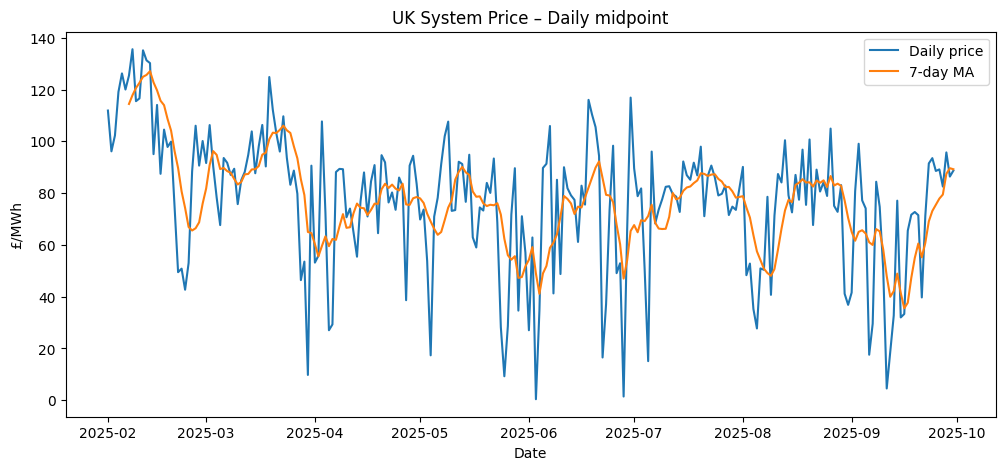

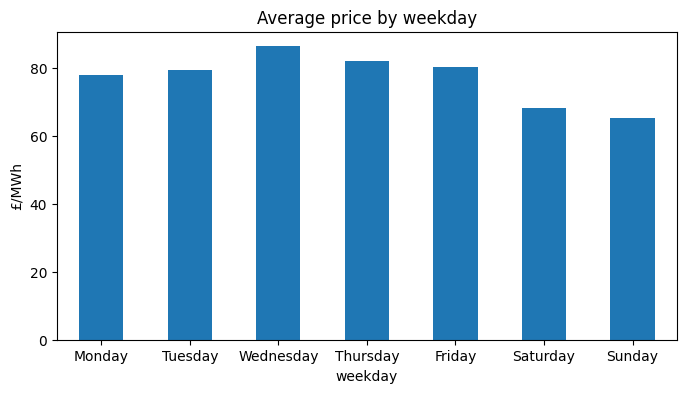

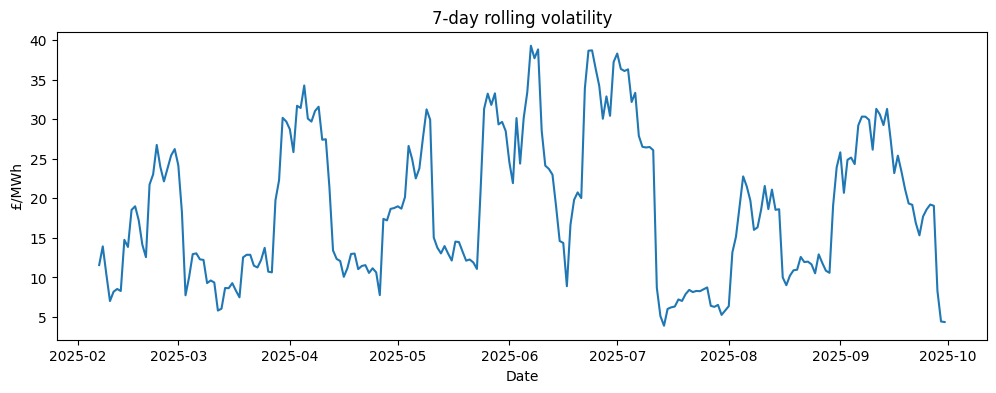

17:06:26 - cmdstanpy - INFO - Chain [1] start processing
17:06:27 - cmdstanpy - INFO - Chain [1] done processing


Hold-out MAPE: 83.63%


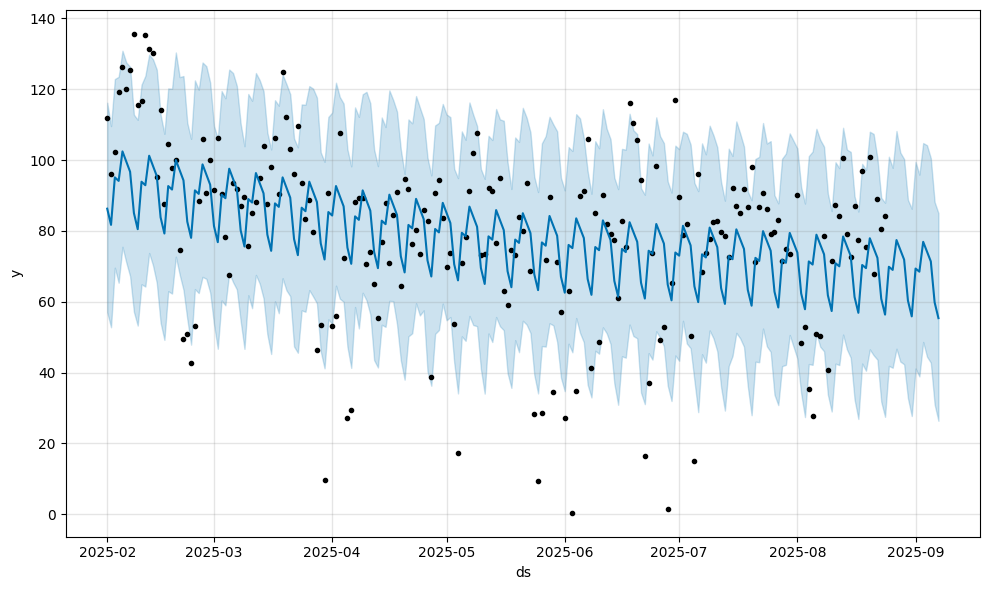

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error as mape

# --- 1) NORMALISE COLUMN NAMES (works with any casing) ---
cmap = {c.lower(): c for c in df.columns}

def pick(*cands):
    for c in cands:
        if c in cmap: 
            return cmap[c]
    raise KeyError(f"Missing any of: {cands}")

DATE = pick("settlementdate","settlement_date","date")
SSP  = pick("systemsellprice","ssp")
SBP  = pick("systembuyprice","sbp")

# --- 2) CLEAN + DAILY MIDPOINT ---
df[DATE] = pd.to_datetime(df[DATE], errors="coerce")
df["ssp"] = pd.to_numeric(df[SSP], errors="coerce")
df["sbp"] = pd.to_numeric(df[SBP], errors="coerce")

df_daily = (
    df.groupby(df[DATE])[["ssp","sbp"]]
      .mean()
      .assign(price=lambda x: x.mean(axis=1))
      .reset_index()
      .rename(columns={DATE: "SettlementDate"})
      .sort_values("SettlementDate")
)

print(df_daily.head())
print(df_daily.describe())

# --- 3) EDA: TREND, WEEKDAY, VOL ---
df_daily["ma7"] = df_daily["price"].rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(df_daily["SettlementDate"], df_daily["price"], label="Daily price")
plt.plot(df_daily["SettlementDate"], df_daily["ma7"],   label="7-day MA")
plt.title("UK System Price – Daily midpoint"); plt.xlabel("Date"); plt.ylabel("£/MWh")
plt.legend(); plt.show()

tmp = df_daily.assign(weekday=df_daily["SettlementDate"].dt.day_name())
ax = (tmp.groupby("weekday")["price"].mean()
        .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
        .plot(kind="bar", figsize=(8,4), rot=0))
ax.set_title("Average price by weekday"); ax.set_ylabel("£/MWh")

df_daily["roll7_std"] = df_daily["price"].rolling(7).std()
plt.figure(figsize=(12,4))
plt.plot(df_daily["SettlementDate"], df_daily["roll7_std"])
plt.title("7-day rolling volatility"); plt.xlabel("Date"); plt.ylabel("£/MWh")
plt.show()

# --- 4) BASELINE PROPHET + HOLD-OUT ---
df_p = df_daily.rename(columns={"SettlementDate":"ds","price":"y"}).dropna(subset=["ds","y"])

split = int(len(df_p)*0.85)
train, test = df_p.iloc[:split], df_p.iloc[split:]

m = Prophet(weekly_seasonality=True, daily_seasonality=False)
m.fit(train)

pred = m.predict(test[["ds"]])[["ds","yhat"]].set_index("ds")
score = mape(test.set_index("ds")["y"], pred["yhat"])
print(f"Hold-out MAPE: {score:.2%}")

# Optional: plot fitted+forecast on full horizon
future = m.make_future_dataframe(periods=14)
fcst = m.predict(future)
m.plot(fcst);


In [47]:
df_daily.to_csv("../data/elexon_prices_daily.csv", index=False)
